<a href="https://colab.research.google.com/github/CS171-Semester-Project/traffic-sign-detection/blob/main/traffic_sign_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [77]:
import os
from google.colab import userdata

In [78]:
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

##**DATA PREPARATION**

In [79]:
# Download the dataset
!kaggle datasets download -d pkdarabi/cardetection

# Unzip the downloaded dataset
!unzip -q cardetection.zip -d cardetection_dataset

Dataset URL: https://www.kaggle.com/datasets/pkdarabi/cardetection
License(s): Attribution 4.0 International (CC BY 4.0)
cardetection.zip: Skipping, found more recently modified local copy (use --force to force download)
replace cardetection_dataset/car/README.dataset.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [80]:
for dirpath, dirnames, filenames in os.walk("cardetection_dataset/car/train"):
    print(f"Train data path: {dirpath}")
    print(f"Train data directories length: {len(dirnames)}")
    print(f"Train data filenames length: {len(filenames)}")

print()

for dirpath, dirnames, filenames in os.walk("cardetection_dataset/car/test"):
    print(f"Test data path: {dirpath}")
    print(f"Test data directories length: {len(dirnames)}")
    print(f"Test data filenames length: {len(filenames)}")

print()

for dirpath, dirnames, filenames in os.walk("cardetection_dataset/car/valid"):
    print(f"Validation data path: {dirpath}")
    print(f"Validation data directories length: {len(dirnames)}")
    print(f"Validation data filenames length: {len(filenames)}")

Train data path: cardetection_dataset/car/train
Train data directories length: 2
Train data filenames length: 1
Train data path: cardetection_dataset/car/train/labels
Train data directories length: 0
Train data filenames length: 3530
Train data path: cardetection_dataset/car/train/images
Train data directories length: 0
Train data filenames length: 3530

Test data path: cardetection_dataset/car/test
Test data directories length: 2
Test data filenames length: 1
Test data path: cardetection_dataset/car/test/labels
Test data directories length: 0
Test data filenames length: 638
Test data path: cardetection_dataset/car/test/images
Test data directories length: 0
Test data filenames length: 638

Validation data path: cardetection_dataset/car/valid
Validation data directories length: 2
Validation data filenames length: 1
Validation data path: cardetection_dataset/car/valid/labels
Validation data directories length: 0
Validation data filenames length: 801
Validation data path: cardetection_da

In [81]:
import yaml

yaml_path = "cardetection_dataset/car/data.yaml"

with open(yaml_path, "r") as f:
    data_info = yaml.safe_load(f)

In [82]:
# Getting all the class or label names
class_names = data_info.get('names', [])
print(f"Total Number of Classes: {len(class_names)}\n")

print("Class Names:")
for i, name in enumerate(class_names):
    print(f"{i}: {name}")

Total Number of Classes: 15

Class Names:
0: Green Light
1: Red Light
2: Speed Limit 10
3: Speed Limit 100
4: Speed Limit 110
5: Speed Limit 120
6: Speed Limit 20
7: Speed Limit 30
8: Speed Limit 40
9: Speed Limit 50
10: Speed Limit 60
11: Speed Limit 70
12: Speed Limit 80
13: Speed Limit 90
14: Stop


In [83]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
import glob

In [84]:
train_images_dir = "cardetection_dataset/car/train/images"
train_labels_dir = "cardetection_dataset/car/train/labels"

if os.path.exists(train_images_dir) and os.path.exists(train_labels_dir):
    image_files = [f for f in os.listdir(train_images_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]
    if image_files:
        random_image = random.choice(image_files)
        # Labels usually have the same base name with a .txt extension in YOLO format
        corresponding_label = os.path.splitext(random_image)[0] + '.txt'

        print(f"Image File: {random_image}")
        print(f"Label File: {corresponding_label}")

        # Verify if the label file actually exists
        if os.path.exists(os.path.join(train_labels_dir, corresponding_label)):
            print("Status: Corresponding label file exists!")
        else:
            print("Status: Corresponding label file is missing.")

Image File: 00014_00009_00025_png.rf.8e82dd2d271ee0b7caf796bc0c069fb4.jpg
Label File: 00014_00009_00025_png.rf.8e82dd2d271ee0b7caf796bc0c069fb4.txt
Status: Corresponding label file exists!


In [85]:
# Get all train images
view_train_img = glob.glob("cardetection_dataset/car/train/images/*.jpg")
if not view_train_img:
    view_train_img = glob.glob("cardetection_dataset/car/valid/images/*.jpg")

In [86]:
# Function to get labels for each image
def get_labels(img_path):
    label_path = img_path.replace("/images/", "/labels/").replace(".jpg", ".txt")
    found_classes = set()
    if os.path.exists(label_path):
        with open(label_path, "r") as f:
            lines = f.readlines()
            for line in lines:
                parts = line.strip().split()
                if len(parts) >= 1:
                    class_id = int(parts[0])
                    if "data_info" in globals() and "names" in data_info:
                        class_name = data_info["names"][class_id]
                    else:
                        class_name = f"Class {class_id}"
                    found_classes.add(class_name)
    if found_classes:
        return f"\nLabel: {", ".join(list(found_classes))}"

    return "\nLabel: None"

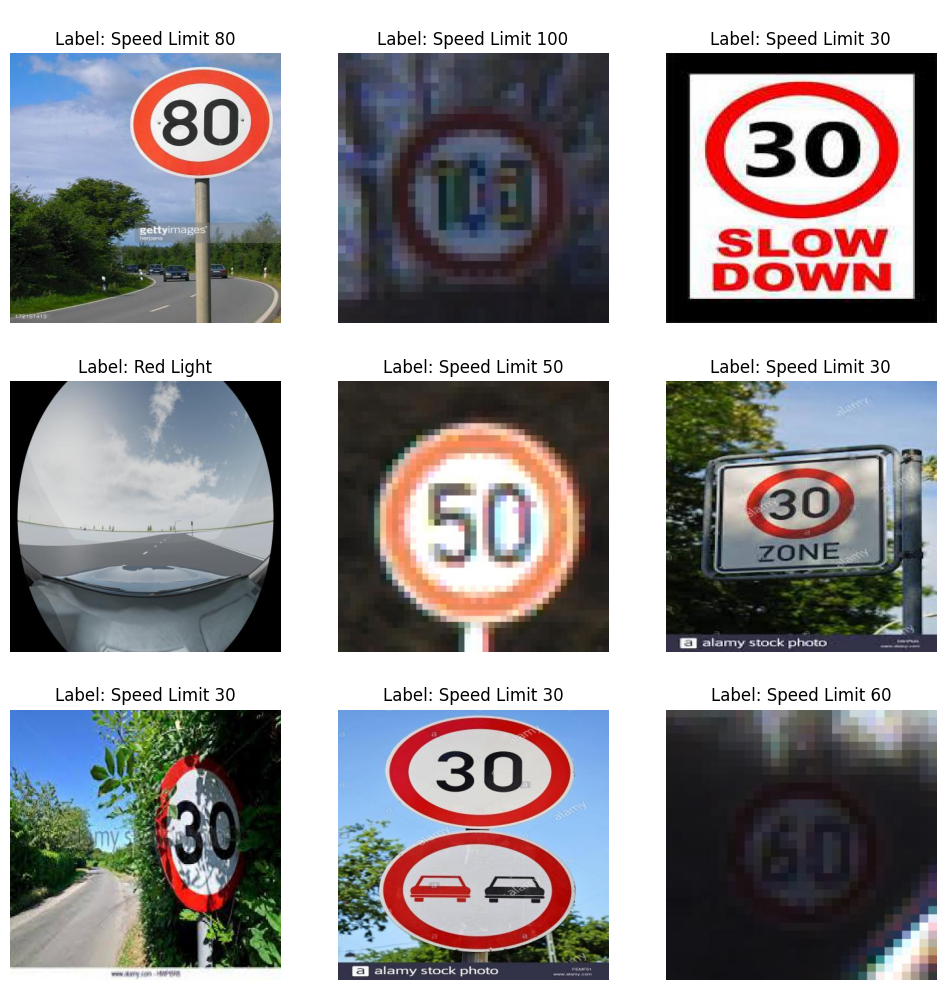

In [87]:
# Visualize multiple train images with labels
samples = random.sample(view_train_img, min(9, len(view_train_img)))
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
axes = axes.flatten()

for i, img_path in enumerate(samples):
    ax =axes[i]
    img = mpimg.imread(img_path)
    ax.imshow(img)
    ax.axis("off")

    title = get_labels(img_path)
    ax.set_title(title)

plt.tight_layout()
plt.show()

In [88]:
train_labels_dir = "cardetection_dataset/car/train/labels"
if os.path.exists(train_labels_dir):
    label_files = os.listdir(train_labels_dir)
    print("Contents of 5 random label files:")

    num_samples = min(5, len(label_files))
    random_files = random.sample(label_files, num_samples)

    for file in random_files:
        file_path = os.path.join(train_labels_dir, file)
        print(f"--- {file} ---")
        with open(file_path, 'r') as f:
            print(f.read())
        print()
else:
    print("Directory not found.")

Contents of 5 random label files:
--- 00001_00023_00021_png.rf.a10de52934dad85b727a4edcd9171235.txt ---
7 0.5480769230769231 0.5552884615384616 0.6225961538461539 0.6658653846153846

--- FisheyeCamera_1_00225_png.rf.065e5230529c71668f7ae887894ac8f4.txt ---
0 0.6201923076923077 0.5120192307692307 0.013221153846153846 0.004807692307692308
1 0.5588942307692307 0.4110576923076923 0.018028846153846152 0.009615384615384616
1 0.4807692307692308 0.421875 0.016826923076923076 0.010817307692307692
10 0.484375 0.5384615384615384 0.016826923076923076 0.02403846153846154

--- 00000_00002_00010_png.rf.a435ef2632ed967a8ddd8a9d54e20a9a.txt ---
6 0.5276442307692307 0.5096153846153846 0.6538461538461539 0.640625

--- 00001_00056_00004_png.rf.614b168b0d7bff36a5bb398b64fcd74f.txt ---
7 0.5384615384615384 0.5072115384615384 0.6514423076923077 0.6862980769230769

--- road503_png.rf.a388f0c85eec8a912762d640fb75bc7f.txt ---
12 0.42788461538461536 0.5408653846153846 0.11538461538461539 0.10216346153846154



In [89]:
import matplotlib.patches as patches

In [90]:
def images_with_bboxes(img_path, ax=None, show_shape=False):
    if ax is None:
        fig, ax = plt.subplots(1)

    img = mpimg.imread(img_path)

    if show_shape:
        print(f"Image Shape: {img.shape} -> (Height, Width, Channels)")

    ax.imshow(img)
    ax.axis("off")

    h, w = img.shape[:2]
    label_path = img_path.replace("/images/", "/labels/").replace(".jpg", ".txt")

    if os.path.exists(label_path):
        with open(label_path, "r") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    class_id = int(parts[0])
                    x_center, y_center, box_w, box_h = map(float, parts[1:])

                    # Convert YOLO format to matplotlib bounding box format (xmin, ymin, width, height)
                    xmin = (x_center - box_w / 2) * w
                    ymin = (y_center - box_h / 2) * h
                    width = box_w * w
                    height = box_h * h

                    class_name = data_info["names"][class_id] if "data_info" in globals() else f"Class {class_id}"

                    # Create and add the bounding box patch
                    rect = patches.Rectangle((xmin, ymin), width, height, linewidth=2, edgecolor='red', facecolor='none')
                    ax.add_patch(rect)

                    # Add class name text
                    ax.text(xmin, ymin - 5, class_name, color='red', fontsize=10, weight='bold',
                            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

Image Shape: (416, 416, 3) -> (Height, Width, Channels)
Image Shape: (416, 416, 3) -> (Height, Width, Channels)
Image Shape: (416, 416, 3) -> (Height, Width, Channels)
Image Shape: (416, 416, 3) -> (Height, Width, Channels)
Image Shape: (416, 416, 3) -> (Height, Width, Channels)
Image Shape: (416, 416, 3) -> (Height, Width, Channels)
Image Shape: (416, 416, 3) -> (Height, Width, Channels)
Image Shape: (416, 416, 3) -> (Height, Width, Channels)
Image Shape: (416, 416, 3) -> (Height, Width, Channels)


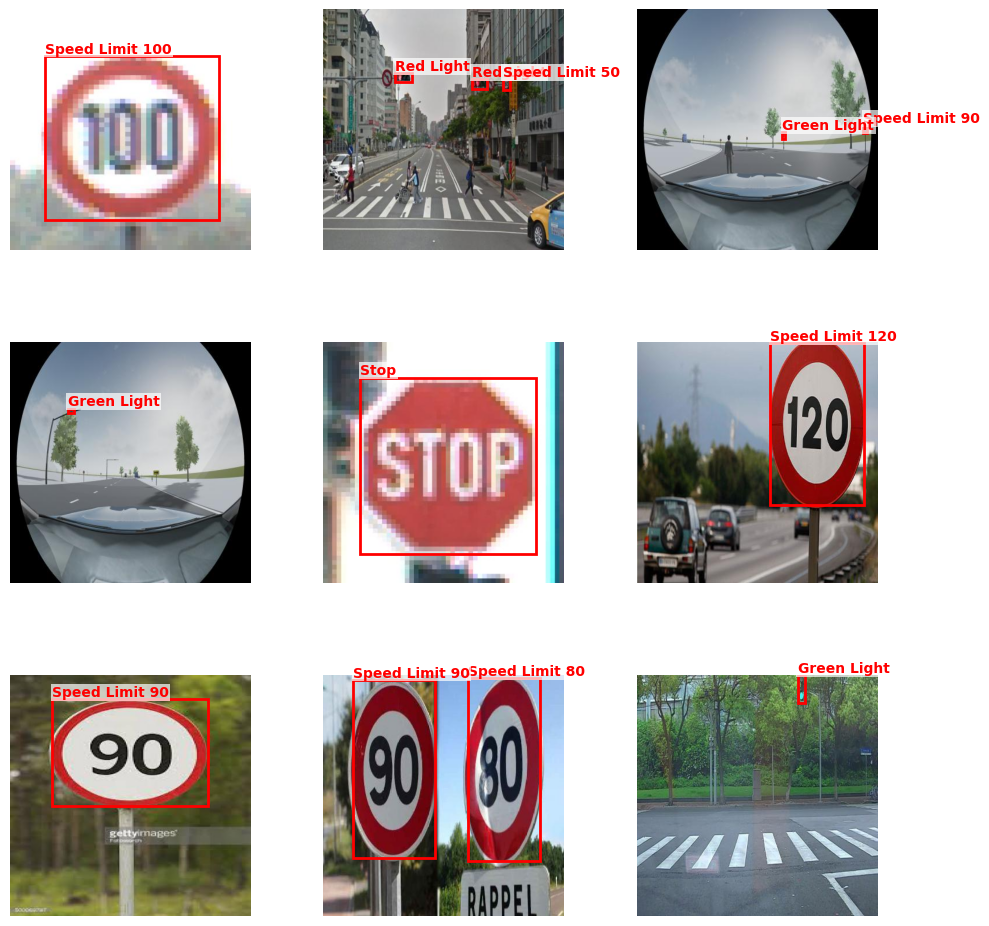

In [91]:
valid_img_paths = glob.glob("cardetection_dataset/car/valid/images/*.jpg")

if valid_img_paths:
    samples = random.sample(valid_img_paths, min(9, len(valid_img_paths)))
    fig, axes = plt.subplots(3, 3, figsize=(10, 10))
    axes = axes.flatten()

    for i, img_path in enumerate(samples):
        images_with_bboxes(img_path, ax=axes[i], show_shape=True)

    plt.tight_layout()
    plt.show()
else:
    print("No validation images found.")

##**DATA PREPROCESSING**

In [92]:
import torch
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

In [95]:
# Function for applying reproducibility globally
def set_seed(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    # Ensure deterministic behavior for cuDNN
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [96]:
class TrafficSignDataset(Dataset):
    def __init__(self, img_dir, label_dir, S=7, B=2, C=15, transform=None):
        self.img_dir = img_dir
        self.label_dir = label_dir
        self.transform = transform
        self.S = S
        self.B = B
        self.C = C
        self.images = [
            f for f in os.listdir(img_dir)
            if f.endswith(('.jpg', '.png', '.jpeg'))
        ]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        img_file = self.images[index]
        img_path = os.path.join(self.img_dir, img_file)

        # Determine corresponding label file path
        label_file = img_file.rsplit('.', 1)[0] + '.txt'
        label_path = os.path.join(self.label_dir, label_file)

        # Parse bounding boxes
        boxes = []
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f.readlines():
                    data = line.strip().split()
                    if data:
                        class_label = int(data[0])
                        x = float(data[1])
                        y = float(data[2])
                        width = float(data[3])
                        height = float(data[4])
                        boxes.append([class_label, x, y, width, height])

        # Load image
        image = Image.open(img_path).convert("RGB")

        # Apply transformations.
        # Note: Since YOLO coordinates are normalized, standard resizing
        # preserves spatial accuracy without altering the bounding box values.
        if self.transform:
            image = self.transform(image)

        # Initialize target tensor
        label_matrix = torch.zeros((self.S, self.S, self.C + 5 * self.B))

        for box in boxes:
            class_label, x, y, width, height = box

            # Grid Assignment
            i, j = int(self.S * y), int(self.S * x)

            # Coordinate Conversion
            x_cell, y_cell = self.S * x - j, self.S * y - i
            width_cell, height_cell = width * self.S, height * self.S

            # Tensor Population
            if label_matrix[i, j, self.C] == 0:
                # Set objectness score to 1
                label_matrix[i, j, self.C] = 1

                # Assign relative box coordinates
                box_coordinates = torch.tensor(
                    [x_cell, y_cell, width_cell, height_cell]
                )
                label_matrix[i, j, self.C + 1: self.C + 5] = box_coordinates

                # Apply one-hot encoding for the class
                label_matrix[i, j, class_label] = 1

        return image, label_matrix

In [97]:
# Define execution parameters
GRID_SIZE = 7
BBOXES = 2
CLASSES = 15
BATCH_SIZE = 8
NUM_WORKERS = 2

# Define transformations
transform_pipeline = transforms.Compose([
    transforms.Resize((416, 416)),
    transforms.ToTensor(),
])

# Define directory paths
train_img_dir = 'cardetection_dataset/car/train/images'
train_label_dir = 'cardetection_dataset/car/train/labels'
val_img_dir = 'cardetection_dataset/car/valid/images'
val_label_dir = 'cardetection_dataset/car/valid/labels'
test_img_dir = 'cardetection_dataset/car/test/images'
test_label_dir = 'cardetection_dataset/car/test/labels'

# Instantiate datasets
train_dataset = TrafficSignDataset(
    img_dir=train_img_dir,
    label_dir=train_label_dir,
    S=GRID_SIZE, B=BBOXES, C=CLASSES,
    transform=transform_pipeline
)

val_dataset = TrafficSignDataset(
    img_dir=val_img_dir,
    label_dir=val_label_dir,
    S=GRID_SIZE, B=BBOXES, C=CLASSES,
    transform=transform_pipeline
)

test_dataset = TrafficSignDataset(
    img_dir=test_img_dir,
    label_dir=test_label_dir,
    S=GRID_SIZE, B=BBOXES, C=CLASSES,
    transform=transform_pipeline
)

# Initialize DataLoaders
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    shuffle=True,
    drop_last=True
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    shuffle=False,
    drop_last=False
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    shuffle=False,
    drop_last=False
)


##**MODEL BUILDING**

###1. CUSTOM MODEL

In [98]:
import torch.nn as nn

In [99]:
class CNNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, **kwargs):
        super(CNNBlock, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, bias=False, **kwargs)
        self.batchnorm = nn.BatchNorm2d(out_channels)
        self.leakyrelu = nn.LeakyReLU(0.1)

    def forward(self, x):
        return self.leakyrelu(self.batchnorm(self.conv(x)))

class TrafficSignDetector(nn.Module):
    def __init__(self, in_channels=3, S=7, B=2, C=15):
        super(TrafficSignDetector, self).__init__()
        self.S = S
        self.B = B
        self.C = C

        self.features = nn.Sequential(
            CNNBlock(in_channels, 64, kernel_size=7, stride=2, padding=3),
            nn.MaxPool2d(kernel_size=2, stride=2),

            CNNBlock(64, 192, kernel_size=3, padding=1),
            nn.MaxPool2d(kernel_size=2, stride=2),

            CNNBlock(192, 128, kernel_size=1),
            CNNBlock(128, 256, kernel_size=3, padding=1),
            CNNBlock(256, 256, kernel_size=1),
            CNNBlock(256, 512, kernel_size=3, padding=1),
            nn.MaxPool2d(kernel_size=2, stride=2),

            CNNBlock(512, 256, kernel_size=1),
            CNNBlock(256, 512, kernel_size=3, padding=1),
            CNNBlock(512, 256, kernel_size=1),
            CNNBlock(256, 512, kernel_size=3, padding=1),
            CNNBlock(512, 256, kernel_size=1),
            CNNBlock(256, 512, kernel_size=3, padding=1),
            CNNBlock(512, 256, kernel_size=1),
            CNNBlock(256, 512, kernel_size=3, padding=1),

            CNNBlock(512, 512, kernel_size=1),
            CNNBlock(512, 1024, kernel_size=3, padding=1),
            nn.MaxPool2d(kernel_size=2, stride=2),

            CNNBlock(1024, 512, kernel_size=1),
            CNNBlock(512, 1024, kernel_size=3, padding=1),
            CNNBlock(1024, 512, kernel_size=1),
            CNNBlock(512, 1024, kernel_size=3, padding=1),

            CNNBlock(1024, 1024, kernel_size=3, padding=1),
            CNNBlock(1024, 1024, kernel_size=3, stride=2, padding=1),
            CNNBlock(1024, 1024, kernel_size=3, padding=1),
            CNNBlock(1024, 1024, kernel_size=3, padding=1)
        )

        # Fully convolutional head to replace linear layers
        self.head = nn.Conv2d(1024, self.C + self.B * 5, kernel_size=1)

    def forward(self, x):
        x = self.features(x)
        x = self.head(x)

        # Reshape to match DataLoader target tensor format
        # Permute from (Batch, Channels, S, S) to (Batch, S, S, Channels)
        x = x.permute(0, 2, 3, 1)
        return x

num_classes = len(class_names)


In [100]:
!pip install torchinfo

In [101]:
# Get model summary
import torchinfo

torchinfo.summary(model=model)

Layer (type:depth-idx)                   Param #
TrafficSignDetector                      --
├─Sequential: 1-1                        --
│    └─CNNBlock: 2-1                     --
│    │    └─Conv2d: 3-1                  4,704
│    │    └─BatchNorm2d: 3-2             64
│    │    └─LeakyReLU: 3-3               --
│    └─MaxPool2d: 2-2                    --
│    └─CNNBlock: 2-3                     --
│    │    └─Conv2d: 3-4                  18,432
│    │    └─BatchNorm2d: 3-5             128
│    │    └─LeakyReLU: 3-6               --
│    └─MaxPool2d: 2-4                    --
│    └─CNNBlock: 2-5                     --
│    │    └─Conv2d: 3-7                  73,728
│    │    └─BatchNorm2d: 3-8             256
│    │    └─LeakyReLU: 3-9               --
│    └─MaxPool2d: 2-6                    --
│    └─CNNBlock: 2-7                     --
│    │    └─Conv2d: 3-10                 8,192
│    │    └─BatchNorm2d: 3-11            128
│    │    └─LeakyReLU: 3-12              --
│    └─CNN

###2. ULTRALYTICS MODELLING

In [102]:
!pip install ultralytics

In [103]:
from IPython.display import Image, display
from ultralytics import YOLO

In [104]:
# Initialize the YOLOv8 Nano architecture
model_ultralytics = YOLO('yolov8n.pt')

In [105]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [106]:
model = TrafficSignDetector(in_channels=3, S=GRID_SIZE, B=BBOXES, C=CLASSES)

##**MODEL TRAINING**

###1. CUSTOM MODEL TRAINING

In [107]:
import torch.optim as optim
from torchvision.ops import box_iou, box_convert

In [108]:
def intersection_over_union(boxes_preds, boxes_labels, box_format="midpoint"):
    """
    Calculates intersection over union element-wise to avoid large N x N memory allocations.
    """
    if box_format == "midpoint":
        box1_x1 = boxes_preds[..., 0:1] - boxes_preds[..., 2:3] / 2
        box1_y1 = boxes_preds[..., 1:2] - boxes_preds[..., 3:4] / 2
        box1_x2 = boxes_preds[..., 0:1] + boxes_preds[..., 2:3] / 2
        box1_y2 = boxes_preds[..., 1:2] + boxes_preds[..., 3:4] / 2

        box2_x1 = boxes_labels[..., 0:1] - boxes_labels[..., 2:3] / 2
        box2_y1 = boxes_labels[..., 1:2] - boxes_labels[..., 3:4] / 2
        box2_x2 = boxes_labels[..., 0:1] + boxes_labels[..., 2:3] / 2
        box2_y2 = boxes_labels[..., 1:2] + boxes_labels[..., 3:4] / 2

    x1 = torch.max(box1_x1, box2_x1)
    y1 = torch.max(box1_y1, box2_y1)
    x2 = torch.min(box1_x2, box2_x2)
    y2 = torch.min(box1_y2, box2_y2)

    # .clamp(0) is for the case when they do not intersect
    intersection = (x2 - x1).clamp(0) * (y2 - y1).clamp(0)

    box1_area = abs((box1_x2 - box1_x1) * (box1_y2 - box1_y1))
    box2_area = abs((box2_x2 - box2_x1) * (box2_y2 - box2_y1))

    return intersection / (box1_area + box2_area - intersection + 1e-6)

class CustomLoss(nn.Module):
    def __init__(self, S=7, B=2, C=15):
        super(CustomLoss, self).__init__()
        self.mse = nn.MSELoss(reduction="sum")
        self.S = S
        self.B = B
        self.C = C
        self.lambda_noobj = 0.5
        self.lambda_coord = 5

    def forward(self, predictions, target):
        predictions = predictions.reshape(-1, self.S, self.S, self.C + self.B * 5)
        target = target.reshape(-1, self.S, self.S, self.C + self.B * 5)

        # Extract bounding boxes for both predictions
        box1_preds = predictions[..., self.C+1 : self.C+5]
        box2_preds = predictions[..., self.C+6 : self.C+10]

        target_boxes = target[..., self.C+1 : self.C+5]

        # Use custom element-wise IoU instead of torchvision's pairwise box_iou
        iou_b1 = intersection_over_union(box1_preds, target_boxes, box_format="midpoint")
        iou_b2 = intersection_over_union(box2_preds, target_boxes, box_format="midpoint")

        ious = torch.cat([iou_b1.unsqueeze(0), iou_b2.unsqueeze(0)], dim=0)
        iou_maxes, bestbox = torch.max(ious, dim=0)

        exists_box = target[..., self.C].unsqueeze(3)

        # For box coordinates
        box_predictions = exists_box * (
            (
                bestbox * predictions[..., self.C+6 : self.C+10]
                + (1 - bestbox) * predictions[..., self.C+1 : self.C+5]
            )
        )
        box_targets = exists_box * target_boxes

        # We add 1e-6 to prevent gradient explosion at derivative of sqrt(0)
        box_predictions[..., 2:4] = torch.sign(box_predictions[..., 2:4]) * torch.sqrt(
            torch.abs(box_predictions[..., 2:4] + 1e-6)
        )
        box_targets[..., 2:4] = torch.sqrt(box_targets[..., 2:4])

        box_loss = self.mse(
            torch.flatten(box_predictions, end_dim=-2),
            torch.flatten(box_targets, end_dim=-2)
        )

        # Object detected loss
        pred_box = (
            bestbox * predictions[..., self.C+5 : self.C+6]
            + (1 - bestbox) * predictions[..., self.C : self.C+1]
        )
        object_loss = self.mse(
            torch.flatten(exists_box * pred_box),
            torch.flatten(exists_box * target[..., self.C : self.C+1])
        )

        # No object detected loss
        no_object_loss = self.mse(
            torch.flatten((1 - exists_box) * predictions[..., self.C : self.C+1], start_dim=1),
            torch.flatten((1 - exists_box) * target[..., self.C : self.C+1], start_dim=1)
        )
        no_object_loss += self.mse(
            torch.flatten((1 - exists_box) * predictions[..., self.C+5 : self.C+6], start_dim=1),
            torch.flatten((1 - exists_box) * target[..., self.C : self.C+1], start_dim=1)
        )

        # Classification loss
        class_loss = self.mse(
            torch.flatten(exists_box * predictions[..., :self.C], end_dim=-2),
            torch.flatten(exists_box * target[..., :self.C], end_dim=-2)
        )

        # Total loss
        loss = (
            self.lambda_coord * box_loss
            + object_loss
            + self.lambda_noobj * no_object_loss
            + class_loss
        )

        return loss / predictions.shape[0]

custom_loss_module = CustomLoss(S=GRID_SIZE, B=BBOXES, C=CLASSES)

def custom_loss(predictions, targets):
    return custom_loss_module(predictions, targets)

optimizer = optim.Adam(params=model.parameters(), lr=0.001)


In [109]:
from tqdm import tqdm
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [111]:
from PIL import Image

LEARNING_RATE = 1e-4
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4) # weight decay for regularization to prevent overfitting
# Learning rate scheduler
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

model.to(device)

# Initialize GradScaler for Mixed Precision Training
scaler = torch.cuda.amp.GradScaler()

def train_fn(train_loader, model, optimizer, loss_fn):
    loop = tqdm(train_loader, leave=True)
    mean_loss = []

    for batch_idx, (x, y) in enumerate(loop):
        x, y = x.to(device), y.to(device)

        # Use Automatic Mixed Precision to save memory
        with torch.cuda.amp.autocast():
            out = model(x)
            loss = loss_fn(out, y)

        mean_loss.append(loss.item())
        optimizer.zero_grad()

        # Backward pass with scaled loss
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # update progress bar
        loop.set_postfix(loss=loss.item())

    return sum(mean_loss) / len(mean_loss)

def val_fn(val_loader, model, loss_fn):
    loop = tqdm(val_loader, leave=True)
    mean_loss = []

    with torch.inference_mode():
        for batch_idx, (x, y) in enumerate(loop):
            x, y = x.to(device), y.to(device)

            with torch.cuda.amp.autocast():
                out = model(x)
                loss = loss_fn(out, y)

            mean_loss.append(loss.item())
            loop.set_postfix(val_loss=loss.item())

    return sum(mean_loss) / len(mean_loss)

epochs = 100
epoch_count = []
loss_values = []
val_loss_values = []

# Empty CUDA cache to free up unallocated memory before training
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print(f"Starting training on {device}...")
for epoch in range(epochs):
    print(f"\nEpoch: {epoch+1}/{epochs}")

    # Training Phase
    model.train()
    avg_loss = train_fn(train_loader, model, optimizer, custom_loss)

    # Validation Phase
    model.eval()
    avg_val_loss = val_fn(val_loader, model, custom_loss)

    # Step the scheduler based on the validation loss
    scheduler.step(avg_val_loss)

    epoch_count.append(epoch + 1)
    loss_values.append(avg_loss)
    val_loss_values.append(avg_val_loss)

    print(f"Epoch {epoch+1} Train Loss: {avg_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

/tmp/ipykernel_564/549701178.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Starting training on cuda...

Epoch: 1/100


  0%|          | 0/441 [00:00<?, ?it/s]/tmp/ipykernel_564/549701178.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
  0%|          | 0/101 [00:00<?, ?it/s]/tmp/ipykernel_564/549701178.py:46: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 101/101 [00:02<00:00, 46.12it/s, val_loss=1.18]


Epoch 1 Train Loss: 6.3008 | Val Loss: 3.0565

Epoch: 2/100


100%|██████████| 101/101 [00:02<00:00, 49.40it/s, val_loss=1.19]


...

Epoch 98 Train Loss: 0.0097 | Val Loss: 0.5364

Epoch: 99/100


100%|██████████| 101/101 [00:02<00:00, 48.16it/s, val_loss=0.0474]


Epoch 99 Train Loss: 0.0096 | Val Loss: 0.5382

Epoch: 100/100


100%|██████████| 101/101 [00:02<00:00, 47.77it/s, val_loss=0.0498]

Epoch 100 Train Loss: 0.0096 | Val Loss: 0.5386


###2. YOLOv8 MODEL TRAINING

In [113]:
# Define the absolute or relative path to the dataset configuration file
yaml_path = 'cardetection_dataset/car/data.yaml'

# Execute the training sequence
results = model_ultralytics.train(
    data=yaml_path,
    epochs=20,
    imgsz=416,
    batch=16,
    device=device, # Designates GPU execution
    project='yolov8_traffic_signs',
    name='train_run'
)

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=cardetection_dataset/car/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train_run-3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mas

##**MODEL TESTING**

In [114]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [115]:
# Gather predicted and actual values
def get_predictions(model, dataloader, device, conf_threshold=0.2, S=GRID_SIZE, B=BBOXES, C=CLASSES):
    model.eval()
    all_preds = []
    all_targets = []

    with torch.inference_mode():
        for images, targets in dataloader:
            images = images.to(device)
            targets = targets.to(device)

            logits = model(images)
            batch_size = logits.shape[0]

            # Reshape predictions and targets
            predictions = logits.reshape(-1, S, S, C + B * 5)
            targets = targets.reshape(-1, S, S, C + B * 5)

            for b in range(batch_size):
                pred = predictions[b]

                # Get classes, confidences, and boxes
                pred_classes = torch.argmax(pred[..., :C], dim=-1)

                # Extract boxes and confidences
                conf1 = pred[..., C:C+1]
                box1 = pred[..., C+1:C+5]
                conf2 = pred[..., C+5:C+6]
                box2 = pred[..., C+6:C+10]

                # Choose the box with the highest confidence for each grid cell
                conf_mask = conf1 > conf2
                best_conf = torch.where(conf_mask, conf1, conf2).squeeze(-1)
                best_box = torch.where(conf_mask.expand_as(box1), box1, box2)

                # Filter by confidence threshold
                mask = best_conf > conf_threshold

                filtered_boxes = best_box[mask]
                filtered_scores = best_conf[mask]
                filtered_classes = pred_classes[mask]

                if filtered_boxes.shape[0] > 0:
                    pred_boxes_xyxy = box_convert(filtered_boxes, in_fmt='cxcywh', out_fmt='xyxy')
                else:
                    pred_boxes_xyxy = torch.empty((0, 4), device=device)

                all_preds.append({
                    'boxes': pred_boxes_xyxy,
                    'scores': filtered_scores,
                    'labels': filtered_classes
                })

                target = targets[b]

                target_conf = target[..., C]
                target_classes = torch.argmax(target[..., :C], dim=-1)
                target_boxes = target[..., C+1:C+5]

                obj_mask = target_conf == 1

                t_boxes = target_boxes[obj_mask]
                t_labels = target_classes[obj_mask]

                if t_boxes.shape[0] > 0:
                    target_boxes_xyxy = box_convert(t_boxes, in_fmt='cxcywh', out_fmt='xyxy')
                else:
                    target_boxes_xyxy = torch.empty((0, 4), device=device)

                all_targets.append({
                    'boxes': target_boxes_xyxy,
                    'labels': t_labels
                })

    return all_preds, all_targets


In [116]:
train_labels, train_preds = get_predictions(model, train_loader, device)
test_labels, test_preds = get_predictions(model, test_loader, device)

##**MODEL EVALUATION**

###1. CUSTOM MODEL EVALUATION

In [117]:
!pip install -q torchmetrics

In [118]:
from sklearn.metrics import f1_score
from torchmetrics.detection.mean_ap import MeanAveragePrecision

In [119]:
def evaluate_model(model, dataloader, device):
    print("Evaluating model...")
    map_metric = MeanAveragePrecision(box_format='xyxy', iou_type='bbox')

    # Get predictions and targets in the format expected by torchmetrics
    preds, targets = get_predictions(model, dataloader, device)

    map_metric.update(preds, targets)
    map_results = map_metric.compute()

    print(f"mAP (IoU=0.50:0.95): {map_results['map']:.4f}")
    print(f"mAP (IoU=0.50): {map_results['map_50']:.4f}")
    print(f"mAP (IoU=0.75): {map_results['map_75']:.4f}")

    return map_results['map']

test_map = evaluate_model(model, test_loader, device)

Evaluating model...
mAP (IoU=0.50:0.95): 0.4448
mAP (IoU=0.50): 0.6083
mAP (IoU=0.75): 0.4804


###2. YOLOv8 MODEL EVALUATION

In [120]:
# Execute validation on the test subset
metrics = model_ultralytics.val(
    split='test',
    project='yolov8_traffic_signs',
    name='val_run'
)

# Output exact Mean Average Precision metrics
print("Quantitative Metrics (Test Set):")
print(f"mAP50-95: {metrics.box.map:.4f}")
print(f"mAP50:    {metrics.box.map50:.4f}")
print(f"mAP75:    {metrics.box.map75:.4f}")

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
Model summary (fused): 73 layers, 3,008,573 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 965.0±419.4 MB/s, size: 20.4 KB)
val: Scanning /content/cardetection_dataset/car/test/labels.cache... 638 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 638/638 99.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 40/40 10.4it/s 3.8s
                   all        638        770      0.793      0.833       0.88      0.739
           Green Light         77        110      0.772      0.791      0.825      0.469
             Red Light         71         94      0.645      0.702      0.656      0.407
        Speed Limit 10          2          3      0.428      0.333      0.618      0.423
       Speed Limit 100         45         46      0.839      0.891      0.952      0.842
       Speed Limit 1

##**EXPERIMENTS FOR THE CUSTOM MODEL**

In [121]:
import pandas as pd
from IPython.display import display

# Initialize the experiments data with placeholders for you to fill
experiments_data = {
    "Experiment Number": [1, 2, 3, 4, 5],
    "Experiment Description": [
        "Baseline",
        "Change GRID_SIZE to 13",
        "Change GRID_SIZE to 16",
        "Reduce the number of convolutional layers in the backbone",
        "Increase epoch count to 150"
    ],
    "GRID_SIZE": [
        7, # Baseline score from previous evaluation
        None,
        None,
        None,
        None
    ],
    "EPOCH": [
        100, # Baseline score from previous evaluation
        None,
        None,
        None,
        None
    ],
    "BATCH_SIZE": [
        8, # Baseline score from previous evaluation
        None,
        None,
        None,
        None
    ],
    "LEARNING_RATE": [
        0.0001, # Baseline score from previous evaluation
        None,
        None,
        None,
        None
    ],
    "Evaluation Score (mAP)": [
        0.4448, # Baseline score from previous evaluation
        None,
        None,
        None,
        None
    ]
}

# Create a pandas DataFrame
experiments_df = pd.DataFrame(experiments_data)

# Display the experiments table
display(experiments_df)

,Experiment Number,Experiment Description,GRID_SIZE,EPOCH,BATCH_SIZE,LEARNING_RATE,Evaluation Score (mAP)
0,1,"Baseline (GRID_SIZE=7, Epochs=100, Original YO...",7.0,100.0,8.0,8.0,0.4448
1,2,Change GRID_SIZE to 13,NaN,NaN,NaN,NaN,NaN
2,3,Change GRID_SIZE to 16,NaN,NaN,NaN,NaN,NaN
3,4,Reduce the number of convolutional layers in t...,NaN,NaN,NaN,NaN,NaN
4,5,Increase epoch count to 150,NaN,NaN,NaN,NaN,NaN


##**VISUALIZATION OF RESULTS**

In [122]:
from sklearn.metrics import confusion_matrix

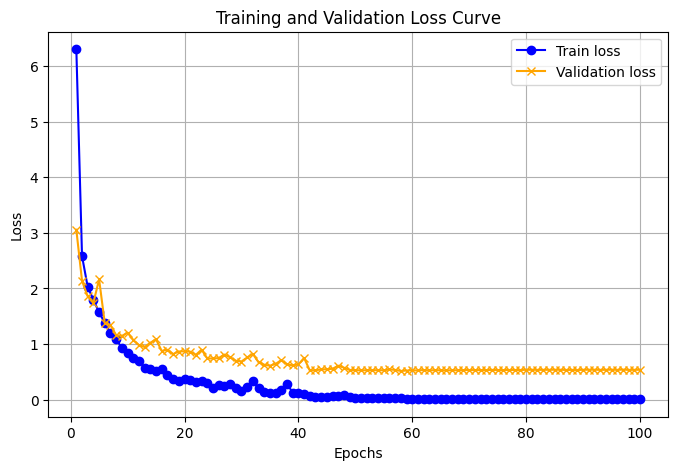

In [123]:
plt.figure(figsize=(8, 5))
plt.plot(epoch_count, loss_values, label="Train loss", color="blue", marker="o")
plt.plot(epoch_count, val_loss_values, label="Validation loss", color="orange", marker="x")
plt.title("Training and Validation Loss Curve")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.grid(True)
plt.legend()
plt.show()

In [124]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
from torchvision.ops import box_iou
import numpy as np

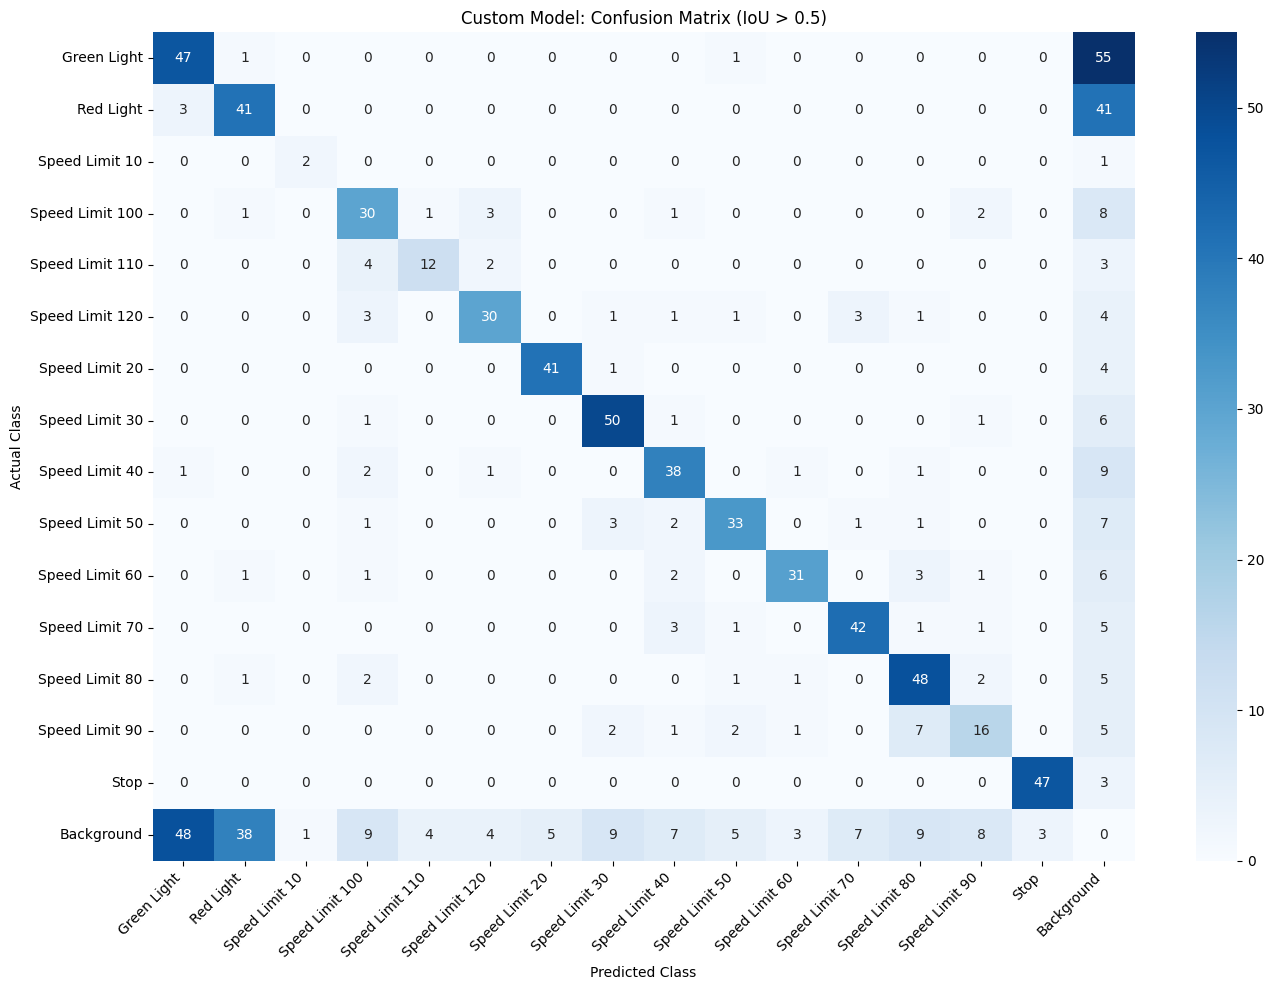

In [125]:
# Get predictions from the test set for the CUSTOM MODEL
preds, targets = get_predictions(model, test_loader, device)

y_true = []
y_pred = []
background_class = 15  # Use class ID 15 for Background

# Match predictions to ground truth targets to build the confusion matrix lists
for i in range(len(targets)):
    t_boxes = targets[i]['boxes']
    t_labels = targets[i]['labels']
    p_boxes = preds[i]['boxes']
    p_labels = preds[i]['labels']

    if len(t_boxes) == 0 and len(p_boxes) == 0:
        continue
    elif len(t_boxes) == 0:
        # All predictions are False Positives (Background truth)
        y_pred.extend(p_labels.cpu().numpy())
        y_true.extend([background_class] * len(p_boxes))
        continue
    elif len(p_boxes) == 0:
        # All targets are False Negatives (Background predicted)
        y_true.extend(t_labels.cpu().numpy())
        y_pred.extend([background_class] * len(t_boxes))
        continue

    # Compute IoU between target and predicted boxes
    ious = box_iou(t_boxes, p_boxes)  # Shape: (N_t, N_p)

    matched_preds = set()
    for t_idx, t_label in enumerate(t_labels):
        best_iou, p_idx = ious[t_idx].max(dim=0)
        if best_iou > 0.5:
            # True Positive or Misclassification
            y_true.append(t_label.item())
            y_pred.append(p_labels[p_idx].item())
            matched_preds.add(p_idx.item())
        else:
            # False Negative (Missed object)
            y_true.append(t_label.item())
            y_pred.append(background_class)

    # Any predictions not matched to a target are False Positives
    for p_idx, p_label in enumerate(p_labels):
        if p_idx not in matched_preds:
            y_pred.append(p_label.item())
            y_true.append(background_class)

# Extend class names with the Background class
ext_class_names = class_names + ["Background"]

# Calculate confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=range(num_classes + 1))

# Plot the heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=ext_class_names, yticklabels=ext_class_names)
plt.title('Custom Model: Confusion Matrix (IoU > 0.5)')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [126]:
import os
from IPython.display import Image, display

# Paths match the project/name parameters used in the validation cell
val_dir = 'yolov8_traffic_signs/val_run'

# YOLOv8 generates both normalized and absolute confusion matrices
confusion_matrix_path = f'{val_dir}/confusion_matrix_normalized.png'
fallback_cm_path = f'{val_dir}/confusion_matrix.png'

print("Ultralytics YOLOv8 Model: Confusion Matrix Heatmap")
if os.path.exists(confusion_matrix_path):
    display(Image(filename=confusion_matrix_path, width=900))
elif os.path.exists(fallback_cm_path):
    display(Image(filename=fallback_cm_path, width=900))
else:
    print(f"File not found. Make sure the YOLOv8 validation step ran successfully.")

Ultralytics YOLOv8 Model: Confusion Matrix Heatmap
File not found. Make sure the YOLOv8 validation step ran successfully.


In [127]:
def plot_predicted_image(img_path, model, device, transform, conf_threshold=0.2, S=GRID_SIZE, B=BBOXES, C=CLASSES):
    img = Image.open(img_path).convert("RGB")
    img_tensor = transform(img).unsqueeze(0).to(device)

    model.eval()
    with torch.inference_mode():
        logits = model(img_tensor)

    pred = logits.reshape(-1, S, S, C + B * 5)[0]

    pred_classes = torch.argmax(pred[..., :C], dim=-1)
    conf1 = pred[..., C:C+1]
    box1 = pred[..., C+1:C+5]
    conf2 = pred[..., C+5:C+6]
    box2 = pred[..., C+6:C+10]

    conf_mask = conf1 > conf2
    best_conf = torch.where(conf_mask, conf1, conf2).squeeze(-1)
    best_box = torch.where(conf_mask.expand_as(box1), box1, box2)

    mask = best_conf > conf_threshold
    filtered_boxes = best_box[mask]
    filtered_classes = pred_classes[mask]
    filtered_scores = best_conf[mask]

    # Get cell indices where objects were detected
    indices = mask.nonzero(as_tuple=False)

    fig, ax = plt.subplots(1, figsize=(8, 8))
    # Resize image to model input size for plotting
    img_np = np.array(img.resize((448, 448)))  # Updated to match the potential 448x448 resize
    ax.imshow(img_np)
    ax.axis("off")

    for idx, box, cls, score in zip(indices, filtered_boxes, filtered_classes, filtered_scores):
        i, j = idx[0].item(), idx[1].item()  # i is row (y), j is col (x)

        # Box coordinates are relative to the grid cell
        x_cell, y_cell, w_cell, h_cell = box.tolist()

        # Convert to global relative coordinates [0, 1]
        x_global = (j + x_cell) / S
        y_global = (i + y_cell) / S
        w_global = w_cell / S
        h_global = h_cell / S

        # Convert to pixel coordinates for the resized image
        w = w_global * 448
        h = h_global * 448
        x = x_global * 448 - w / 2
        y = y_global * 448 - h / 2

        class_name = class_names[cls.item()]

        rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='red', facecolor='none')
        ax.add_patch(rect)
        ax.text(x, y - 5, f"{class_name} ({score:.2f})", color='red', fontsize=10, weight='bold',
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

    plt.title("Model Prediction on Random Test Image")
    plt.tight_layout()
    plt.show()


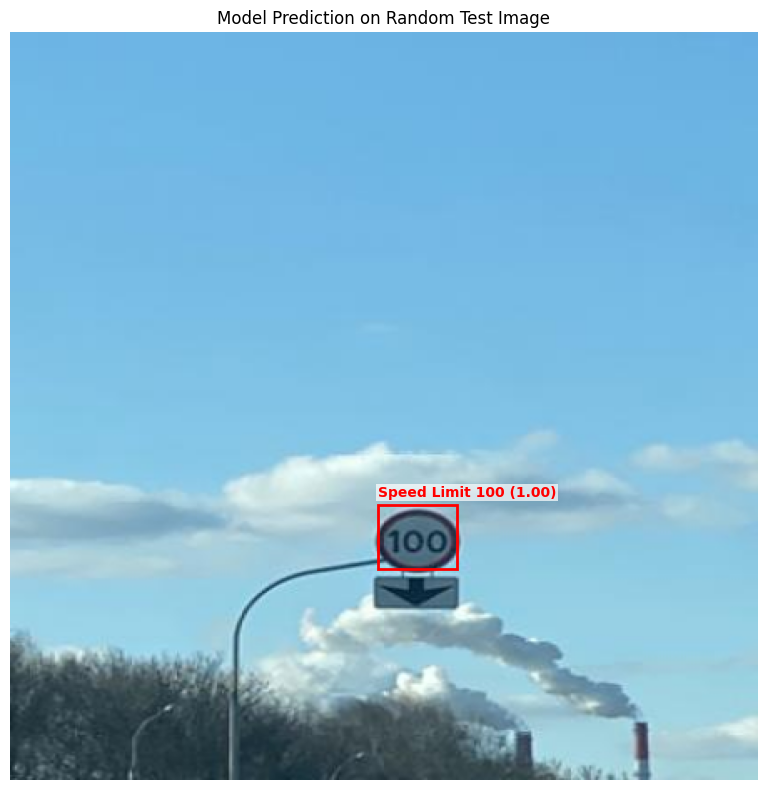

In [131]:
from PIL import Image
import glob
import random

test_images = glob.glob("cardetection_dataset/car/test/images/*.jpg")
if test_images:
    random_test_img = random.choice(test_images)
    plot_predicted_image(random_test_img, model, device, transform_pipeline)
else:
    print("No test images found.")


0: 416x416 1 Speed Limit 120, 1.9ms
1: 416x416 1 Speed Limit 30, 1.9ms
2: 416x416 (no detections), 1.9ms
3: 416x416 (no detections), 1.9ms
4: 416x416 1 Speed Limit 100, 1.9ms
Speed: 0.8ms preprocess, 1.9ms inference, 0.8ms postprocess per image at shape (1, 3, 416, 416)
Results saved to /content/runs/detect/yolov8_traffic_signs/predict_run-4
Visual Inference Samples:


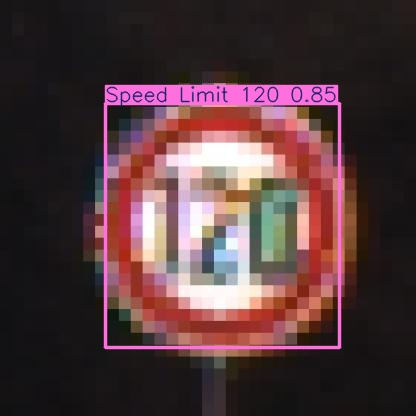

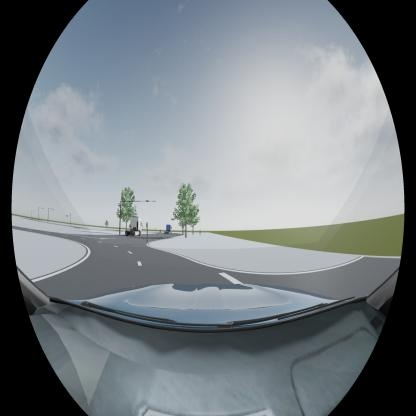

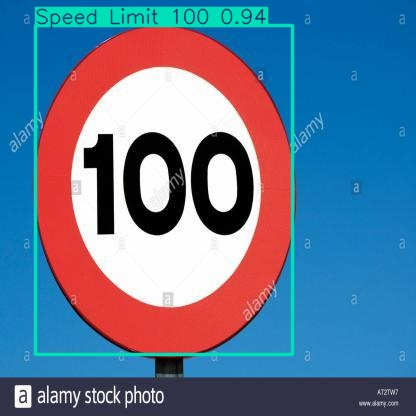

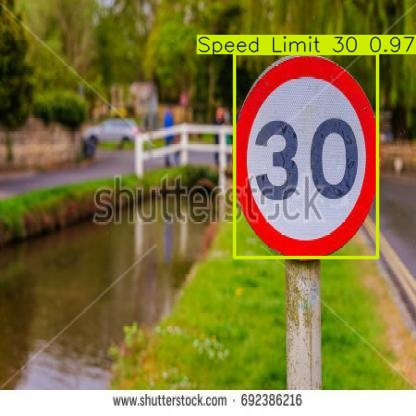

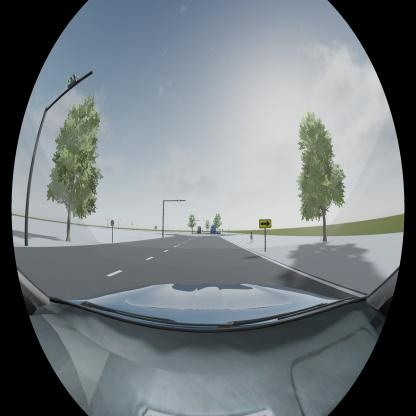

In [133]:
import glob
from IPython.display import Image, display

# Retrieve sample images from the test directory
test_dir = 'cardetection_dataset/car/test/images/*.jpg'
sample_images = glob.glob(test_dir)[:5]

# Execute inference and save spatial predictions
predict_results = model_ultralytics.predict(
    source=sample_images,
    conf=0.25,
    save=True,
    project='yolov8_traffic_signs',
    name='predict_run'
)

# Display the annotated output images
# Use the save_dir from the first result to get the correct output folder
predicted_images_dir = predict_results[0].save_dir
predicted_images = glob.glob(f'{predicted_images_dir}/*.jpg')

print("Visual Inference Samples:")
for img_path in predicted_images:
    display(Image(filename=img_path, width=600))